# Mixed-Field Ising Model (MFIM) evolution using Matrix Product Operator (MPO)

with bond dimension χ controlled by operator entanglement.



In [266]:
# using Pkg; Pkg.add("ITensors"); Pkg.add("ITensorMPS")
using ITensors, ITensorMPS
# using Pkg; Pkg.add("LaTeXStrings")
using LaTeXStrings
using Plots

#include("../src/matrix_product_operator_functions.jl")
include("matrix_product_operator_functions.jl")
import .mpo_functions as mpo

## MFIM's Hamiltonian

$$H = \sum_j ( X_j X_{j+1} + gX_j + hZ_j ) \quad \text{with} \quad g=1/2, h=1/2$$

In [267]:
g = 0.5
h = 0.5

0.5

---
# 1. Introduction

Before we gonna focus on a simple and controlled setting in order to validate the method and build intuition before moving to more complex circuits and operator.

We consider a system of $N=12$ qubits (particles $1/2$) arranged on a 1D chain. The quantum dynamics is generated by a circuit composed of **two-qubit gates** applied in a **bricklayer pattern**.

In [268]:
# nombre de spins
N = 12

# creation des sites
sites = ITensors.siteinds("S=1/2", N)

12-element Vector{Index{Int64}}:
 (dim=2|id=48|"S=1/2,Site,n=1")
 (dim=2|id=246|"S=1/2,Site,n=2")
 (dim=2|id=886|"S=1/2,Site,n=3")
 (dim=2|id=991|"S=1/2,Site,n=4")
 (dim=2|id=916|"S=1/2,Site,n=5")
 (dim=2|id=762|"S=1/2,Site,n=6")
 (dim=2|id=993|"S=1/2,Site,n=7")
 (dim=2|id=695|"S=1/2,Site,n=8")
 (dim=2|id=359|"S=1/2,Site,n=9")
 (dim=2|id=889|"S=1/2,Site,n=10")
 (dim=2|id=846|"S=1/2,Site,n=11")
 (dim=2|id=738|"S=1/2,Site,n=12")

---

# 2. Temporal evolution

In the Heisenberg picture, the evolution applies to the operator.

We will therefore seek here to evolve our operator $\hat{O}$,
which is defined by:

$$\hat{O}(t) = U^{\dagger}\hat{O}U$$

Let us then calculate the evolution operator $U = e^{-iHt}$.

Calculating $U$ for $N$ that is too large is too computationally expensive, we will seek to simplify it by using:

### Trotter decomposition

$$H = \sum_j h_{j,j+1} \quad \text{where} \quad h_{j,j+1} = X_jX_{j+1} +\frac{g}{2}( X_j+X_{j+1})+\frac{h}{2}( Z_j+Z_{j+1})$$

$H$ can be decompose between $j_{odd}$ and $j_{even}$ so $H = H_{odd} + H_{even}$.

We take a small time step $\tau << 1$,
we can use the Baker-Campbell-Hausdorff formula to approximate :

$$U(\tau) = e^{-i \tau H} = e^{-i \tau (H_{odd} + H_{even})} = e^{-i \tau H_o} e^{-i \tau H_e} e^{-i \tau^2 [H_o,H_e]} = e^{-i \tau H_o} e^{-i \tau H_e} + O(\tau^2)$$
because of
$$e^{-i \tau^2 [H_o,H_e]} = \mathbb{I} - i \tau^2 [H_o, H_e] + O(\tau^4) $$

We have an error per time step $\tau$ of order $\tau^2$.

the $h_{j,j+1}$ for $j$ odd or even commute with each other, so

$$e^{-i \tau H_o} = e^{-i \tau \sum_{j_{odd}}h_{j,j+1}} = \prod_{j_{odd}} e^{-i \tau h_{j,j+1}} $$

same for $H_{even}$.

in conclusion we take

$$U^{TEBD2}(\tau) = e^{-iH\tau} \approx \prod_{j_{odd}}e^{-i\tau h_{j,j+1}/2} \prod_{j_{even}}e^{-i\tau h_{j,j+1}} \prod_{j_{odd}}e^{-i\tau h_{j,j+1}/2}$$

Wich have an error order of $\tau^3$.

Each term: $e^{-i\tau h_{j,j+1}}$ acts only on 2 spins.
Therefore, it can be represented as a 4-index tensor.
This is called a **TEBD gate**.

In [315]:
# Hamiltonien local h_{j,j+1}
function build_two_site_hamiltonian(j::Int64, N::Int64, g::Float64=0.5, h::Float64=0.5)
  s1 = sites[j]
  s2 = sites[j + 1]

  # Terme d'interaction ZZ
  hj = op("X", s1) * op("X", s2)

  # Gestion du champ pour le site de gauche (s1)
  # Si on est au bord gauche (j=1), on met le champ complet, sinon la moitié
  g1 = (j == 1) ? g : g/2
  h1 = (j == 1) ? h : h/2
  hj += g1 * (op("X", s1) * op("Id", s2)) + h1 * (op("Z", s1) * op("Id", s2))

  # Gestion du champ pour le site de droite (s2)
  # Si on est au bord droit (j=N-1), on met le champ complet, sinon la moitié
  g2 = (j == N - 1) ? g : g/2
  h2 = (j == N - 1) ? h : h/2
  hj += g2 * (op("Id", s1) * op("X", s2)) + h2 * (op("Id", s1) * op("Z", s2))

  return hj
end

# Construction des gates TEBD
function build_gates_hj(τ::Float64, N::Int64, g::Float64=0.5, h::Float64=0.5)
  gates_odd = ITensor[]
  gates_even = ITensor[]
  for j in 1:(N-1)
      hj = build_two_site_hamiltonian(j, N, g, h)
      if isodd(j)
        Gj = exp(-im * τ / 2 * hj)
        push!(gates_odd, Gj)
      else
        Gj = exp(-im * τ * hj)
        push!(gates_even, Gj)
      end
  end
  return gates_odd, gates_even
end

function compute_MFIM_circuit(Nqubits::Int64, nlayers::Int64, τ::Float64, g::Float64=0.5, h::Float64=0.5)
  gates_odd, gates_even = build_gates_hj(τ, Nqubits, g, h)

  # On crée une seule liste ordonnée pour un pas de Trotter complet
  # Ordre : Odd (τ/2) -> Even (τ) -> Odd (τ/2)
  one_step_layer = vcat(gates_odd, gates_even, gates_odd)

  return [one_step_layer for _ in 1:nlayers]
end

compute_MFIM_circuit (generic function with 3 methods)

---

# 3. Evolution of the Identity

If $\hat{O} = \mathbb{I}$ we have :

$$U^\dagger \mathbb{I} U = \mathbb{I} \qquad \forall U \text{ unitary}$$

Let's test the robustness of our method by verifying this result.

In [270]:
# construction MPO identite
IdMPO = MPO(sites, "Id")

println("Max bond dimension = ", maxlinkdim(IdMPO))

Max bond dimension = 1


max bond dimension $= 1 \implies \chi = 1$, it's the simpliest MPO possible.

In [271]:
# Simulation
cutoff = 1e-8
τ = 0.1
steps = 100

circuit = compute_MFIM_circuit(N, steps, τ, g, h)
psi0 = MPS(siteinds(first, IdMPO), ["Up" for _ in 1:N]) # |↑↑..↑>

Ot, result = mpo.propagate_layerbylayer(circuit, IdMPO; cutoff, psi0)

println("Max bond dimension = ", maxlinkdim(Ot))
println("\nIdentity distance = ", norm(Ot - IdMPO))

layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by mpo_functions.propagate_layerbylayer: 8.035660982131958 seconds
Max bond dimension = 1

Identity distance = 1.0394463127401881e-13


This indeed gives the expected result:
$$U^{\dagger}\mathbb{I}U = \mathbb{I}$$
After applying the evolution, we arrive back at the identity, with a **numerical error** of the order of $10^{-13}$ for $100$ steps.

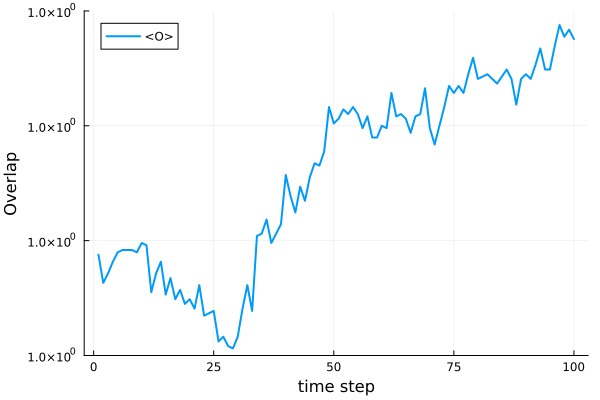

Average Overlap : 1.0000000000000056 ≈ 1


In [272]:
overlap_values = result["overlap"]

p = plot(1:steps, overlap_values,
     xlabel="time step",
     ylabel="Overlap",
     label="<O>",
     lw=2)
display(p)

import Statistics: mean
println("Average Overlap : ", mean(overlap_values)," ≈ 1")

And the overlap $\langle \uparrow | \mathbb I | \uparrow \rangle \approx 1$.

---

# 4. Propagation of a local operator

Let's take $\hat{O} = Z_3$ as an example of a local operator.

$$Z_3 = \mathbb{I} \otimes \mathbb{I} \otimes Z \otimes \mathbb{I} \otimes \dots \otimes \mathbb{I}$$


In [273]:
# Z_3
j = 3

ops = ["Id" for n in 1:N]
ops[j] = "Z"
Z_j = MPO(sites, ops)

println("Max bond dimension = ", maxlinkdim(Z_j))

Max bond dimension = 1


For $Z_3$, we obtain $\chi = 1$ so this is indeed a local operator.

Let's see if the operator propagates correctly through the chain and if it remains local

---

## 4.1 Propagation

we take the bond $N/2$, It is at this index that we separate our system into two parts, and then calculate the entropy between these two blocks.

In [274]:
# Simulation
bond = N÷2

cutoff = 1e-8
τ = 0.1
steps = 100

circuit = compute_MFIM_circuit(N, steps, τ, g, h)

Z_jt, result = mpo.propagate_layerbylayer(circuit, Z_j; cutoff)

println("Max bond dimension = ", maxlinkdim(Z_jt))
println("Theorical Max bond dim = ", 2^N) # 2^N = dim max of the matrix

layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by mpo_functions.propagate_layerbylayer: 7410.347739934921 seconds
Max bond dimension = 1665
Theorical Max bond dim = 4096


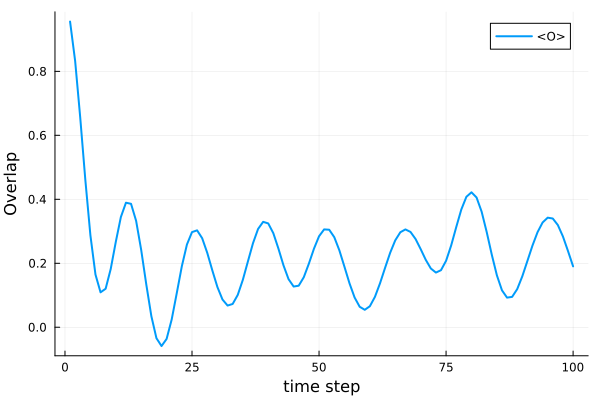

In [279]:
overlap_values = result["overlap"]

plot(1:steps, overlap_values,
     xlabel="time step",
     ylabel="Overlap",
     label="<O>",
     lw=2)

---

## 4.2 Max bond dimenstion ($\chi$)

With the MPO method, we use a cutoff to reduce computation time.
When the max bond reaches $2^N$, this means either that our system is far too entangled, or that our cutoff is not large enough.

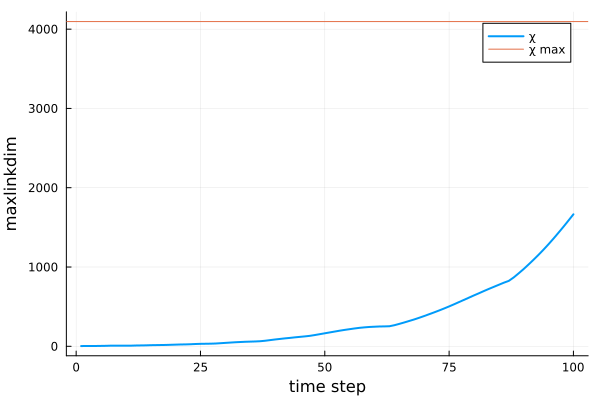

In [276]:
chi_values = result["maxbond"]

plot(1:steps, chi_values,
     xlabel="time step",
     ylabel="maxlinkdim",
     label="χ",
     lw=2)
hline!([2^N], label="χ max")

We observe an increase in the maximum bond dimension and a growth in $\chi$ due to operator entanglement caused by $X_jX_{j+1}$ in the Hamiltonian.

The bond dimension $\chi$ measures operator entanglement if the cutoff isn't too large.

---

# 5. Operator Entanglement

If we divide the system into two parts: $A | B$

We would like to know 'how far' an operator $\hat{O}(t)$ is from a product operator,
$$\hat O \approx O^A \otimes O^B$$

The operator can be rewritten as a matrix:

$$\hat{O} = \sum_\alpha s_\alpha A_\alpha \otimes B_\alpha$$

where:
- $s_\alpha =$  singular values
- $A_\alpha$ acts on A
- $B_\alpha$ acts on B

This is a Schmidt decomposition of the operator.

### Operator Entanglement Entropy

is useful to determine whether an operator can be approximated by a Matrix Product Operator with small bond dimension

$$S_{op} = - \sum_{\alpha } p_\alpha log(p_\alpha)$$

with
$$p_\alpha = \frac{s_\alpha^2}{\sum_\beta s_\beta^2}$$


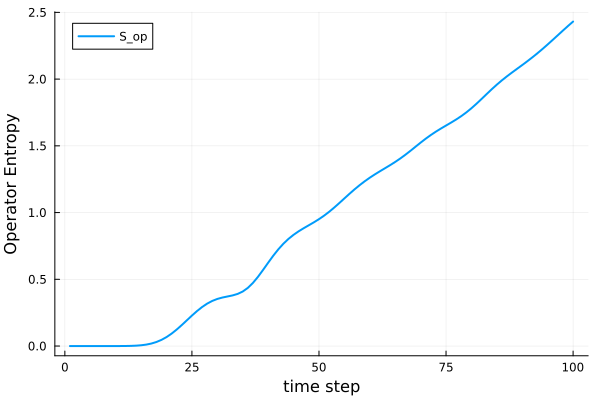

In [277]:
S_values = result["S"]

plot(1:steps, S_values,
     xlabel="time step",
     ylabel="Operator Entropy",
     label="S_op",
     lw=2)

---

$$\chi \approx e^{S_{op}}? $$

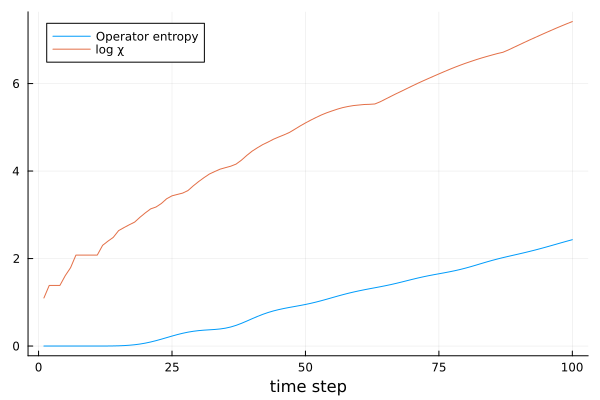

In [278]:
plot(1:steps, S_values,
     label="Operator entropy",
     xlabel="time step")

plot!(1:steps, log.(chi_values),
      label="log χ")

---

# Annexe

In [324]:
nqubits = 2
nlayers = 150
dt = 0.1

# creation des sites, on a besoin de l'init avant le circuit
sites = ITensors.siteinds("S=1/2", nqubits)

# circuit
circuit = compute_MFIM_circuit(nqubits, nlayers, dt, 0.0, 0.0)

# observable
ops = ["Id" for n in 1:nqubits]
ops[1] = "Z"
Z_i = MPO(sites, ops)

# propagation
Z_i_t, _ = mpo.propagate_layerbylayer(circuit, Z_i)
print("---")

layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by mpo_functions.propagate_layerbylayer: 9.79010796546936 seconds
---

In [325]:
Zitensor = ITensor(1.)
for i = 1:nqubits
  Zitensor *= Z_i_t[i]
end

Z1_t_mpo = Array(Zitensor, sites[1]', sites[2]', sites[1], sites[2])
Z1_t_mpo = reshape(Z1_t_mpo, 4, 4)
@show Z1_t_mpo

Z1_t_mpo = ComplexF64[0.15425144988759446 - 1.5965642212747522e-16im -1.3277513686878456e-14 + 1.9104739298839765e-15im 1.038653896087359e-15 + 6.79318254371939e-16im 9.71445146547012e-16 + 0.9880316240928916im; -1.0194056643098933e-14 - 1.9104739310589315e-15im -0.15425144988758693 + 1.5965642212764113e-16im 1.8596235662471372e-15 - 0.9880316240928807im -4.3558823976160014e-16 - 1.690116916963661e-15im; -8.040449461172093e-16 + 5.942871746206789e-16im 1.4155343563970746e-15 + 0.9880316240928942im 0.15425144988759243 + 4.700139195154205e-17im -1.4190931697376894e-14 + 1.2832704454068784e-15im; 1.4155343563970746e-15 - 0.9880316240928834im 1.4071106024428794e-15 - 1.605085837212408e-15im -9.280638632600197e-15 - 1.2832704465818694e-15im -0.1542514498875849 - 4.700139195136482e-17im]


4×4 Matrix{ComplexF64}:
     0.154251-1.59656e-16im  …   9.71445e-16+0.988032im
 -1.01941e-14-1.91047e-15im     -4.35588e-16-1.69012e-15im
 -8.04045e-16+5.94287e-16im     -1.41909e-14+1.28327e-15im
  1.41553e-15-0.988032im           -0.154251-4.70014e-17im

In [327]:
import LinearAlgebra as la

#------- init matrix -------#
I_mat = ComplexF64[1 0;
                   0 1]

Z = ComplexF64[1  0;
               0 -1]

Y = ComplexF64[0 -1im;
               1im 0]

X = ComplexF64[0 1;
               1 0]

#------- Analytic data -------#
Z1 = kron(Z, I_mat)
H = kron(X, X)
U = exp(-1im * dt * H / 2) # U = e^{-i * dt * H /2}
U_dagger = U'

Z1_t_analytic = copy(Z1)
for _ in 1:nlayers
    global Z1_t_analytic = U_dagger * Z1_t_analytic * U # Z1(t) = U^\dagger Z1(t-dt) U
end

#------- result print -------#
is_close = isapprox(Z1_t_mpo, Z1_t_analytic, rtol=1e-5)
println("Is the analytical calculation close to the Pauli propagation result?  ", is_close)

error_val = la.norm(Z1_t_mpo - Z1_t_analytic)
println("with an error of :  ", error_val)

Is the analytical calculation close to the Pauli propagation result?  false
with an error of :  2.828427124746247


---

## References

- [Julia documentation](https://docs.julialang.org/en/v1/)
- [ITensor documentation](https://docs.itensor.org/ITensors/stable/index.html)
- https://docs.juliaplots.org/dev/tutorial/
- https://www.phys.ens.psl.eu/~jacobsen/AMP21_Dubail.pdf
- https://tensornetwork.org/mps/algorithms/timeevo/tebd.html